# 4. Evaluation

EEEM075 - AI and Sustainability coursework

First and only look at the **held-out test set (2015)**. Loads the tuned MLP and tuned XGBoost from Notebook 3, evaluates both on test, compares them on model size and inference/training cost, and applies SHAP so the predictions can be explained rather than treated as a black box.

In [13]:
import json
import time
import os
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

import xgboost as xgb
import shap

import matplotlib.pyplot as plt

ARTIFACT_DIR = Path('../artifacts')
MODEL_DIR = ARTIFACT_DIR / 'models'

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

FEATURES = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP']
TARGET = 'NOX'

In [14]:
train = pd.read_csv(ARTIFACT_DIR / 'train.csv')
test = pd.read_csv(ARTIFACT_DIR / 'test.csv')

X_train = train[FEATURES].values
X_test, y_test = test[FEATURES].values, test[TARGET].values

scaler = joblib.load(MODEL_DIR / 'scaler.joblib')
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Test set (2015):', X_test.shape, '— first time this data has been used.')

Test set (2015): (7384, 9) — first time this data has been used.


In [15]:
def evaluate(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label:>20} | RMSE: {rmse:.3f}  MAE: {mae:.3f}  R2: {r2:.3f}')
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

## Load the tuned models

The MLP architecture has to be redefined here (notebooks are meant to run independently in sequence) - it's rebuilt using the exact hyperparameters saved by Notebook 3, then the trained weights are loaded in.

In [16]:
class MLP(nn.Module):
    def __init__(self, n_features, hidden=(64, 32), dropout=0.1):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers += [nn.Linear(in_dim, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [17]:
with open(MODEL_DIR / 'mlp_tuned_params.json') as f:
    mlp_params = json.load(f)
mlp_params['hidden'] = tuple(mlp_params['hidden'])
print('Loaded MLP params:', mlp_params)

mlp = MLP(n_features=len(FEATURES), hidden=mlp_params['hidden'], dropout=mlp_params['dropout'])
mlp.load_state_dict(torch.load(MODEL_DIR / 'mlp_tuned.pt'))
mlp.eval()

with open(MODEL_DIR / 'xgb_tuned_params.json') as f:
    xgb_params = json.load(f)
print('Loaded XGBoost params:', xgb_params)

xgb_model = xgb.XGBRegressor()
xgb_model.load_model(str(MODEL_DIR / 'xgb_tuned.json'))

Loaded MLP params: {'hidden': (128, 64, 32), 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001}
Loaded XGBoost params: {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.6, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0}


## Test-set performance

This is the first and only time either model touches the 2015 data. Numbers here - not the earlier validation numbers - are what should be reported as the project's headline results.

In [18]:
with torch.no_grad():
    mlp_test_pred = mlp(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy()
mlp_test_metrics = evaluate(y_test, mlp_test_pred, 'MLP (test)')

xgb_test_pred = xgb_model.predict(X_test)
xgb_test_metrics = evaluate(y_test, xgb_test_pred, 'XGBoost (test)')

          MLP (test) | RMSE: 11.689  MAE: 10.181  R2: -0.103
      XGBoost (test) | RMSE: 14.270  MAE: 13.126  R2: -0.643


## Model size and computational cost

Required comparison: size (parameters / disk footprint) and speed (training time already logged in Notebook 3; inference latency measured here). This baseline table is what Notebook 5's compression results get compared against.

In [19]:
# --- Size ---
mlp_n_params = sum(p.numel() for p in mlp.parameters())
mlp_disk_kb = os.path.getsize(MODEL_DIR / 'mlp_tuned.pt') / 1024

xgb_n_trees = xgb_model.get_booster().num_boosted_rounds()
xgb_disk_kb = os.path.getsize(MODEL_DIR / 'xgb_tuned.json') / 1024

print(f'MLP     : {mlp_n_params:,} parameters, {mlp_disk_kb:.1f} KB on disk')
print(f'XGBoost : {xgb_n_trees} trees, {xgb_disk_kb:.1f} KB on disk')

MLP     : 11,649 parameters, 49.1 KB on disk
XGBoost : 300 trees, 1780.3 KB on disk


In [20]:
# --- Inference latency (mean per-sample time over the full test set, repeated for stability) ---
N_REPEATS = 5

mlp_times = []
X_test_scaled_t = torch.tensor(X_test_scaled, dtype=torch.float32)
with torch.no_grad():
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        _ = mlp(X_test_scaled_t)
        mlp_times.append((time.perf_counter() - t0) / len(X_test_scaled_t))

xgb_times = []
for _ in range(N_REPEATS):
    t0 = time.perf_counter()
    _ = xgb_model.predict(X_test)
    xgb_times.append((time.perf_counter() - t0) / len(X_test))

mlp_latency_ms = np.mean(mlp_times) * 1000
xgb_latency_ms = np.mean(xgb_times) * 1000

print(f'MLP     mean inference latency: {mlp_latency_ms:.5f} ms/sample')
print(f'XGBoost mean inference latency: {xgb_latency_ms:.5f} ms/sample')

MLP     mean inference latency: 0.00172 ms/sample
XGBoost mean inference latency: 0.01086 ms/sample


The MLP is the more computationally efficient model on both counts: ~49 KB on disk against ~1.8 MB for XGBoost (300 trees of depth 6 serialise to a large file), and roughly 6× faster per prediction (~0.0017 ms vs ~0.0109 ms per sample). These figures are the uncompressed baseline that the compression results in Notebook 5 are measured against.

In [21]:
efficiency_results = pd.DataFrame({
    'MLP': {**mlp_test_metrics, 'n_params_or_trees': mlp_n_params, 'disk_kb': mlp_disk_kb, 'latency_ms': mlp_latency_ms},
    'XGBoost': {**xgb_test_metrics, 'n_params_or_trees': xgb_n_trees, 'disk_kb': xgb_disk_kb, 'latency_ms': xgb_latency_ms},
}).T

print(efficiency_results)
efficiency_results.to_csv(ARTIFACT_DIR / 'test_efficiency_results.csv')

              rmse        mae        r2  n_params_or_trees      disk_kb  \
MLP      11.688527  10.181241 -0.102544            11649.0    49.102539   
XGBoost  14.270012  13.125931 -0.643331              300.0  1780.340820   

         latency_ms  
MLP        0.001723  
XGBoost    0.010863  


## Explainable AI (SHAP)

Both models are explained with the same model-agnostic `shap.Explainer`, wrapped around each model's predict function, run against a background sample drawn from training data and evaluated on a subset of the test set for speed.

**Note on method:** the original plan was `TreeExplainer` for XGBoost (exact and faster for tree models), but the installed `xgboost`/`shap` versions hit a known compatibility bug - XGBoost serialises an internal `base_score` value in a bracketed format (`'[6.877653E1]'`) that this `shap` version's `TreeExplainer` fails to parse. Rather than change package versions mid-project, both models use the same generic `Explainer` here, which never touches that code path. This also gives a consistent, directly comparable SHAP methodology across both models.

In [22]:
SHAP_BACKGROUND_N = 100
SHAP_EXPLAIN_N = 200

rng = np.random.RandomState(SEED)
bg_idx = rng.choice(len(X_train), size=SHAP_BACKGROUND_N, replace=False)
explain_idx = rng.choice(len(X_test), size=SHAP_EXPLAIN_N, replace=False)

ExactExplainer explainer: 201it [00:51,  3.30it/s]                         
C:\Users\Acer\AppData\Local\Temp\ipykernel_31788\2785034560.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


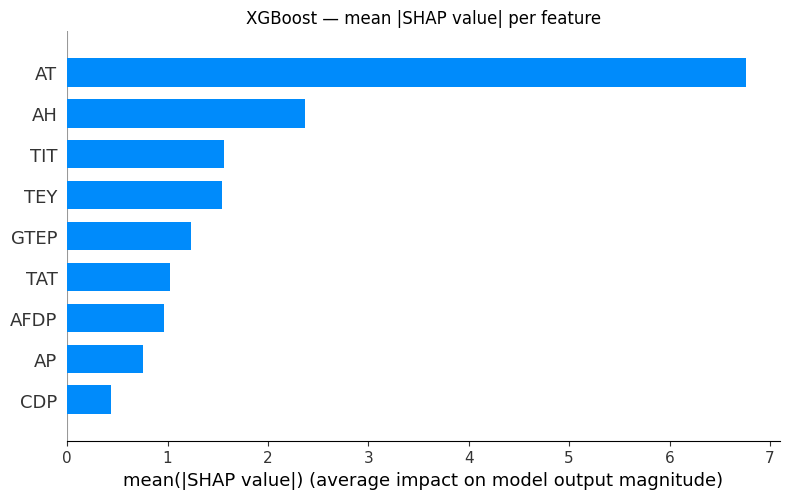

In [23]:
# --- XGBoost: model-agnostic Explainer on raw (unscaled) features ---
def xgb_predict(x):
    return xgb_model.predict(x)

xgb_explainer = shap.Explainer(xgb_predict, X_train[bg_idx], feature_names=FEATURES)
xgb_shap_values = xgb_explainer(X_test[explain_idx])

shap.summary_plot(
    xgb_shap_values.values, X_test[explain_idx], feature_names=FEATURES,
    plot_type='bar', show=False,
)
plt.title('XGBoost — mean |SHAP value| per feature')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'shap_xgb_bar.png', dpi=150)
plt.show()

ExactExplainer explainer: 201it [00:12,  2.80it/s]                         
C:\Users\Acer\AppData\Local\Temp\ipykernel_31788\4042307295.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


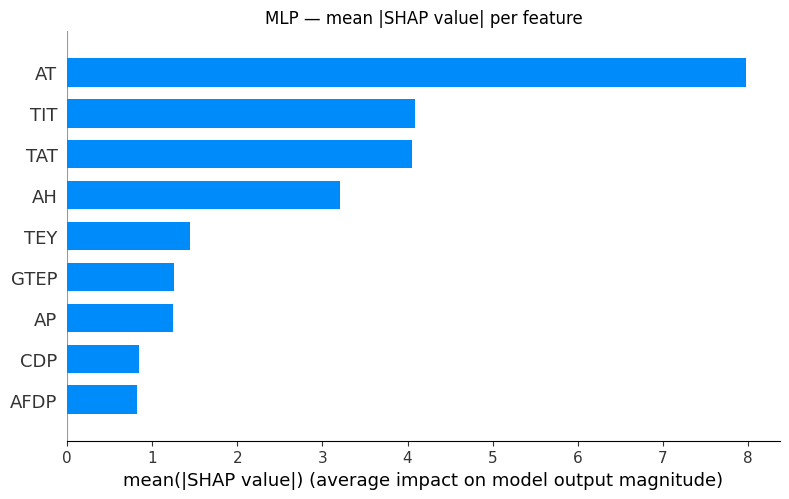

In [24]:
# --- MLP: model-agnostic Explainer on scaled features ---
def mlp_predict(x_scaled):
    with torch.no_grad():
        return mlp(torch.tensor(x_scaled, dtype=torch.float32)).numpy()

mlp_explainer = shap.Explainer(mlp_predict, X_train_scaled[bg_idx], feature_names=FEATURES)
mlp_shap_values = mlp_explainer(X_test_scaled[explain_idx])

shap.summary_plot(
    mlp_shap_values.values, X_test_scaled[explain_idx], feature_names=FEATURES,
    plot_type='bar', show=False,
)
plt.title('MLP — mean |SHAP value| per feature')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'shap_mlp_bar.png', dpi=150)
plt.show()

## Reading the SHAP output against combustion physics

Both models agree that `AT` (ambient temperature) is by far the most influential feature (mean |SHAP| ≈ 8.0 for the MLP, ≈ 6.8 for XGBoost), consistent with the strong negative AT-NOx correlation found in the EDA. Below that, the two models differ: the MLP leans heavily on `TIT` and `TAT` (≈ 4.0 each) - the combustion-temperature variables - while XGBoost ranks `AH` second and gives the temperature variables less weight. This partially resolves the counter-intuitive EDA finding: the weak *linear* NOx-TIT correlation was hiding a stronger non-linear temperature effect, which the MLP exploits. The dominance of ambient conditions matches the physics (colder, denser intake air raises flame temperature and thermal NOx formation), but it also means predictions rest heavily on ambient variables rather than turbine operating state - which helps explain why performance degrades when the ambient-to-NOx relationship shifts across years.